# Step 08: Multi-Crop Data Loading & Validation
## MandiMitra ML Pipeline — Tomato, Wheat, Cotton (Maharashtra 2024–2026)

Load and validate raw AGMARKNET CSV files. Rice files are completely ignored.

### 1. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
BASE_DIR = Path('..').resolve()
if str(BASE_DIR) not in sys.path:
    sys.path.append(str(BASE_DIR))
from src.multi_crop_data_loader import run_all_crops
print('Step 08: Multi-Crop Data Loading')

Step 08: Multi-Crop Data Loading


### 2. Load and Combine All 9 Raw CSVs

In [2]:
all_results = run_all_crops(verbose=True)


CROP: TOMATO
  tomato2024.csv: 10,508 rows | 2024-01-01 to 2024-12-31
  tomato2025.csv: 11,006 rows | 2025-01-01 to 2025-12-31
  tomato2026.csv: 7,560 rows | 2026-01-01 to 2026-09-03
  Combined total: 29,074 rows | 2024-01-01 to 2026-09-03
  Unique markets: 60 | Varieties: 2 | Grades: 2
  Missing values: 0
  Saved: data/processed/maharashtra_tomato_2024_2026_combined.csv
  Saved validation: outputs/tomato_data_validation.csv

CROP: WHEAT
  wheat2024.csv: 18,338 rows | 2024-01-01 to 2024-12-31


  wheat2025.csv: 21,703 rows | 2025-01-01 to 2025-12-31


  wheat2026.csv: 17,914 rows | 2026-01-01 to 2026-09-03
  Combined total: 57,955 rows | 2024-01-01 to 2026-09-03
  Unique markets: 242 | Varieties: 7 | Grades: 3
  Missing values: 0
  Saved: data/processed/maharashtra_wheat_2024_2026_combined.csv
  Saved validation: outputs/wheat_data_validation.csv

CROP: COTTON
  cotton2024.csv: 4,979 rows | 2024-01-01 to 2024-12-31
  cotton2025.csv: 4,403 rows | 2025-01-01 to 2025-12-31
  cotton2026.csv: 2,933 rows | 2026-01-01 to 2026-08-14
  Combined total: 12,315 rows | 2024-01-01 to 2026-08-14
  Unique markets: 86 | Varieties: 8 | Grades: 3


  Missing values: 0
  Saved: data/processed/maharashtra_cotton_2024_2026_combined.csv
  Saved validation: outputs/cotton_data_validation.csv

MULTI-CROP DATA SUMMARY
  crop  rows start_date   end_date  unique_markets  unique_varieties  unique_grades  missing_values  exact_duplicates
Tomato 29074 2024-01-01 2026-09-03              60                 2              2               0                 0
 Wheat 57955 2024-01-01 2026-09-03             242                 7              3               0                 0
Cotton 12315 2024-01-01 2026-08-14              86                 8              3               0                 0

Saved summary: outputs/multi_crop_data_summary.csv


### 3. Combined Dataset Summary Table

In [3]:
summary_df = pd.read_csv(BASE_DIR / 'outputs' / 'multi_crop_data_summary.csv')
print('MULTI-CROP DATA SUMMARY')
display(summary_df)

MULTI-CROP DATA SUMMARY


,crop,rows,start_date,end_date,unique_markets,unique_varieties,unique_grades,missing_values,exact_duplicates
0,Tomato,29074,2024-01-01,2026-09-03,60,2,2,0,0
1,Wheat,57955,2024-01-01,2026-09-03,242,7,3,0,0
2,Cotton,12315,2024-01-01,2026-08-14,86,8,3,0,0


### 4. Per-Crop Column & Type Audit

In [4]:
for crop, (df, stats) in all_results.items():
    print(f'\n{crop.upper()} — dtypes:')
    print(df.dtypes)
    print(f'  Rows: {len(df):,} | Missing: {df.isna().sum().sum()} | Dups: {df.duplicated().sum()}')


TOMATO — dtypes:
State/UT                      str
District                      str
Market                        str
Commodity Group               str
Commodity                     str
Variety                       str
Grade                         str
Min Price                 float64
Max Price                 float64
Modal Price               float64
Price Unit                    str
Price Date         datetime64[us]
dtype: object
  Rows: 29,074 | Missing: 0 | Dups: 0

WHEAT — dtypes:
State/UT                      str
District                      str
Market                        str
Commodity Group               str
Commodity                     str
Variety                       str
Grade                         str
Min Price                 float64
Max Price                 float64
Modal Price               float64
Price Unit                    str
Price Date         datetime64[us]
dtype: object
  Rows: 57,955 | Missing: 0 | Dups: 0

COTTON — dtypes:
State/UT                   

### 5. Schema Compatibility Check

In [5]:
expected = ['State/UT','District','Market','Commodity Group','Commodity','Variety','Grade',
            'Min Price','Max Price','Modal Price','Price Unit','Price Date']
all_ok = True
for crop, (df, _) in all_results.items():
    missing = [c for c in expected if c not in df.columns]
    print(f'  {crop}: {"COMPATIBLE" if not missing else f"MISSING {missing}"}')
    if missing: all_ok = False
print(f'\n[{"PASSED" if all_ok else "FAILED"}] All crop CSVs share identical 12-column AGMARKNET schema.')

  Tomato: COMPATIBLE
  Wheat: COMPATIBLE
  Cotton: COMPATIBLE

[PASSED] All crop CSVs share identical 12-column AGMARKNET schema.


### 6. Observations by Year

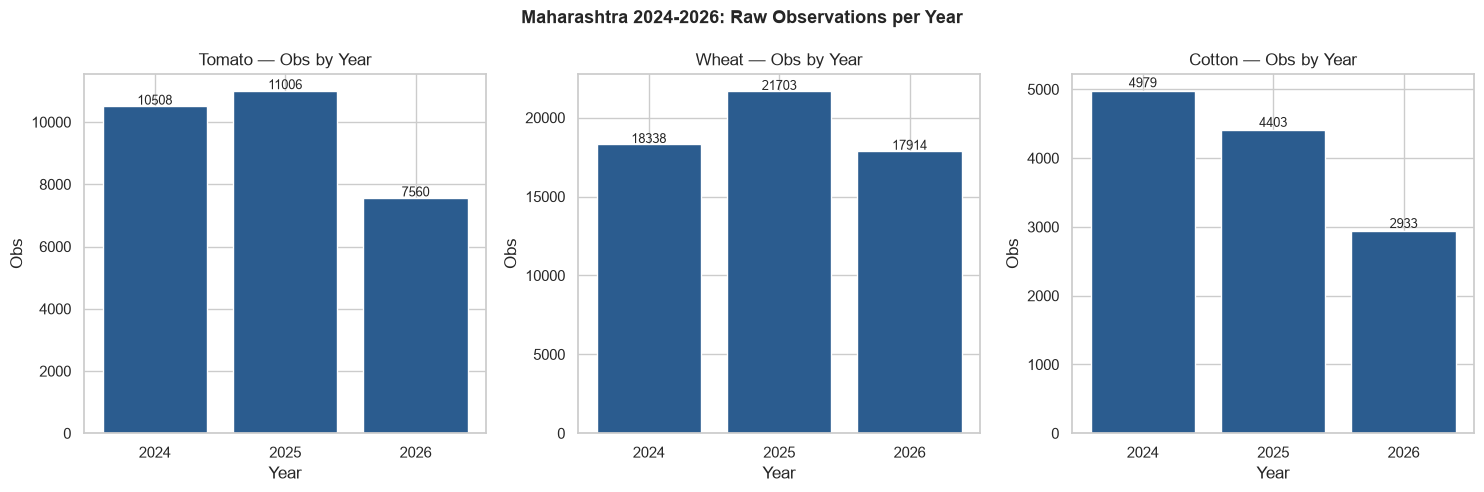

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (crop, (df, _)) in zip(axes, all_results.items()):
    yc = df['Price Date'].dt.year.value_counts().sort_index()
    ax.bar(yc.index.astype(str), yc.values, color='#2b5c8f')
    ax.set_title(f'{crop} — Obs by Year'); ax.set_xlabel('Year'); ax.set_ylabel('Obs')
    for i,v in enumerate(yc.values): ax.text(i, v+50, str(v), ha='center', fontsize=9)
plt.suptitle('Maharashtra 2024-2026: Raw Observations per Year', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR/'outputs'/'eda'/'multi_crop_obs_by_year.png', dpi=120, bbox_inches='tight')
plt.show()

### 7. Rice Protection & File Validation

In [7]:
rice_files = ['maharashtra_2024_2026_combined.csv','maharashtra_rice_modeling_clean.csv',
              'maharashtra_rice_features.csv','maharashtra_rice_train.csv','maharashtra_rice_test.csv']
for rf in rice_files:
    p = BASE_DIR/'data'/'processed'/rf
    print(f'  [{"OK" if p.exists() else "MISSING"}] Rice protected: {rf}')
for crop in ['tomato','wheat','cotton']:
    p = BASE_DIR/'data'/'processed'/f'maharashtra_{crop}_2024_2026_combined.csv'
    print(f'  [{"CREATED" if p.exists() else "MISSING"}] New combined: {p.name}')

  [OK] Rice protected: maharashtra_2024_2026_combined.csv
  [OK] Rice protected: maharashtra_rice_modeling_clean.csv
  [OK] Rice protected: maharashtra_rice_features.csv
  [OK] Rice protected: maharashtra_rice_train.csv
  [OK] Rice protected: maharashtra_rice_test.csv
  [CREATED] New combined: maharashtra_tomato_2024_2026_combined.csv
  [CREATED] New combined: maharashtra_wheat_2024_2026_combined.csv
  [CREATED] New combined: maharashtra_cotton_2024_2026_combined.csv


### 8. Step 08 Completion

In [8]:
print('='*60)
print('STEP 08 — MULTI-CROP DATA LOADING COMPLETE')
print('='*60)
for crop, (df, stats) in all_results.items():
    print(f'  {crop}: {stats["rows"]:,} rows | {stats["start_date"]} to {stats["end_date"]} | {stats["unique_markets"]} markets | {stats["unique_varieties"]} varieties | {stats["unique_grades"]} grades')

STEP 08 — MULTI-CROP DATA LOADING COMPLETE
  Tomato: 29,074 rows | 2024-01-01 to 2026-09-03 | 60 markets | 2 varieties | 2 grades
  Wheat: 57,955 rows | 2024-01-01 to 2026-09-03 | 242 markets | 7 varieties | 3 grades
  Cotton: 12,315 rows | 2024-01-01 to 2026-08-14 | 86 markets | 8 varieties | 3 grades
